In [2]:
import sys
sys.path.insert(0, ".")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from src.features.feature_engineering import (
    add_all_features,
    add_calendar_features,
    add_lag_features,
    add_rolling_features,
    add_holiday_features,
    show_features
)



In [3]:
df = pd.read_parquet("data/processed/train_clean.parquet")

print("Loaded clean data")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head(3)

Loaded clean data
Shape: (421570, 18)
Columns: ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Month', 'WeekOfYear']


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Month,WeekOfYear
0,1,1,2010-02-05,24924.50,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2,5
1,1,1,2010-02-12,46039.49,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2,6
2,1,1,2010-02-19,41595.55,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2,7


In [4]:
df_features = add_all_features(df)

print("\nShape after features:", df_features.shape)
df_features.head(3)

Adding calendar features...
Adding lag features...
Adding rolling average features...
Adding holiday features...
Removed 13134 rows with missing lag values (expected)
Done! Total features: 46 columns

Shape after features: (408436, 46)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,rolling_std_8,rolling_mean_12,rolling_std_12,rolling_mean_26,rolling_std_26,rolling_max_4,rolling_min_4,is_holiday,weeks_to_next_holiday,weeks_from_last_holiday
4,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.0,...,12832.106391,32990.770000,12832.106391,32990.770000,12832.106391,46039.49,19403.54,0,27,3
5,1,1,2010-03-12,21043.39,False,A,151315,57.79,2.667,0.0,...,12182.739805,30758.196000,12182.739805,30758.196000,12182.739805,46039.49,19403.54,0,26,4
6,1,1,2010-03-19,22136.64,False,A,151315,54.58,2.720,0.0,...,11595.899933,29139.061667,11595.899933,29139.061667,11595.899933,41595.55,19403.54,0,25,5


In [5]:
show_features(df_features)

Total features created: 30

Lag features (7):
  ['lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'lag_26', 'lag_52']

Rolling features (10):
  ['rolling_mean_4', 'rolling_std_4', 'rolling_mean_8', 'rolling_std_8', 'rolling_mean_12', 'rolling_std_12', 'rolling_mean_26', 'rolling_std_26', 'rolling_max_4', 'rolling_min_4']

Calendar + Holiday features (13):
  ['Month', 'WeekOfYear', 'month', 'week_of_year', 'quarter', 'year', 'day_of_year', 'is_december', 'is_q4', 'year_progress', 'is_holiday', 'weeks_to_next_holiday', 'weeks_from_last_holiday']


In [6]:
# Look at Store 1, Dept 1 — check that lag_1 is actually 1 week behind
check = df_features[
    (df_features["Store"] == 1) &
    (df_features["Dept"] == 1)
][["Date", "Weekly_Sales", "lag_1", "lag_4", "lag_52"]].head(10)

print("Lag feature check (Store 1, Dept 1):")
print(check.to_string())
print()
print("lag_1 should equal the Weekly_Sales from the row above it — check this!")

Lag feature check (Store 1, Dept 1):
         Date  Weekly_Sales     lag_1     lag_4  lag_52
4  2010-03-05      21827.90  19403.54  24924.50     NaN
5  2010-03-12      21043.39  21827.90  46039.49     NaN
6  2010-03-19      22136.64  21043.39  41595.55     NaN
7  2010-03-26      26229.21  22136.64  19403.54     NaN
8  2010-04-02      57258.43  26229.21  21827.90     NaN
9  2010-04-09      42960.91  57258.43  21043.39     NaN
10 2010-04-16      17596.96  42960.91  22136.64     NaN
11 2010-04-23      16145.35  17596.96  26229.21     NaN
12 2010-04-30      16555.11  16145.35  57258.43     NaN
13 2010-05-07      17413.94  16555.11  42960.91     NaN

lag_1 should equal the Weekly_Sales from the row above it — check this!


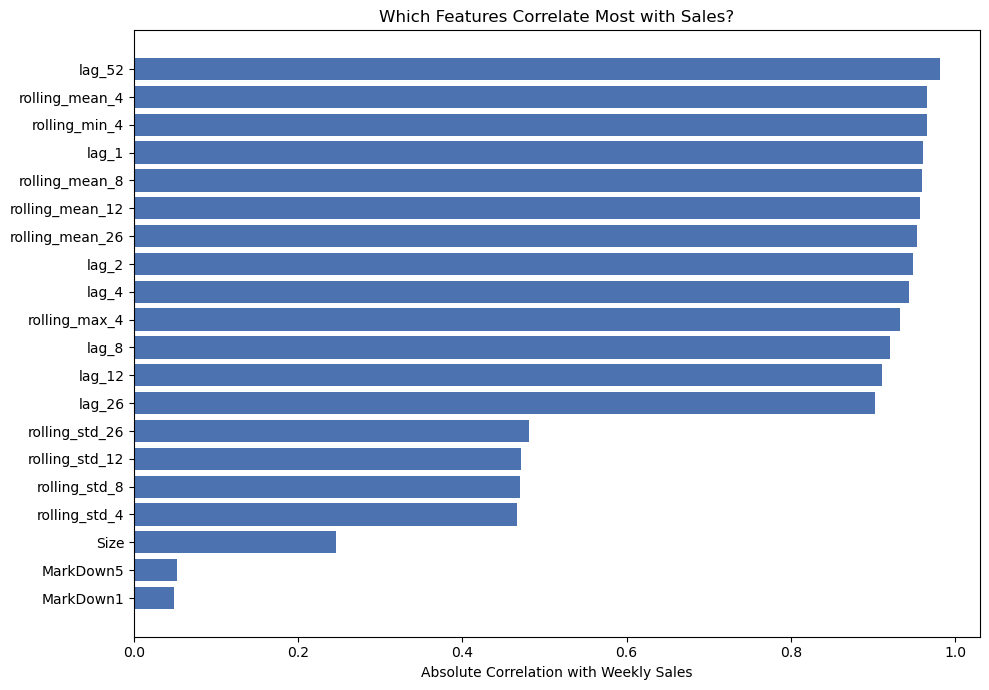

Higher bar = more useful feature for prediction


In [7]:
# Pick numeric feature columns only
feature_cols = [c for c in df_features.columns
                if c not in ["Store", "Dept", "Date", "IsHoliday", "Type"]
                and df_features[c].dtype in ["float32", "float64", "int32", "int64"]]

# Calculate correlation with Weekly_Sales
correlations = df_features[feature_cols].corr()["Weekly_Sales"].drop("Weekly_Sales")
correlations = correlations.abs().sort_values(ascending=False).head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#4C72B0" if v > 0 else "#C44E52"
          for v in df_features[correlations.index].corrwith(df_features["Weekly_Sales"])]
ax.barh(correlations.index[::-1], correlations.values[::-1], color=colors[::-1])
ax.set_xlabel("Absolute Correlation with Weekly Sales")
ax.set_title("Which Features Correlate Most with Sales?")
plt.tight_layout()
plt.savefig("reports/figures/07_feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Higher bar = more useful feature for prediction")

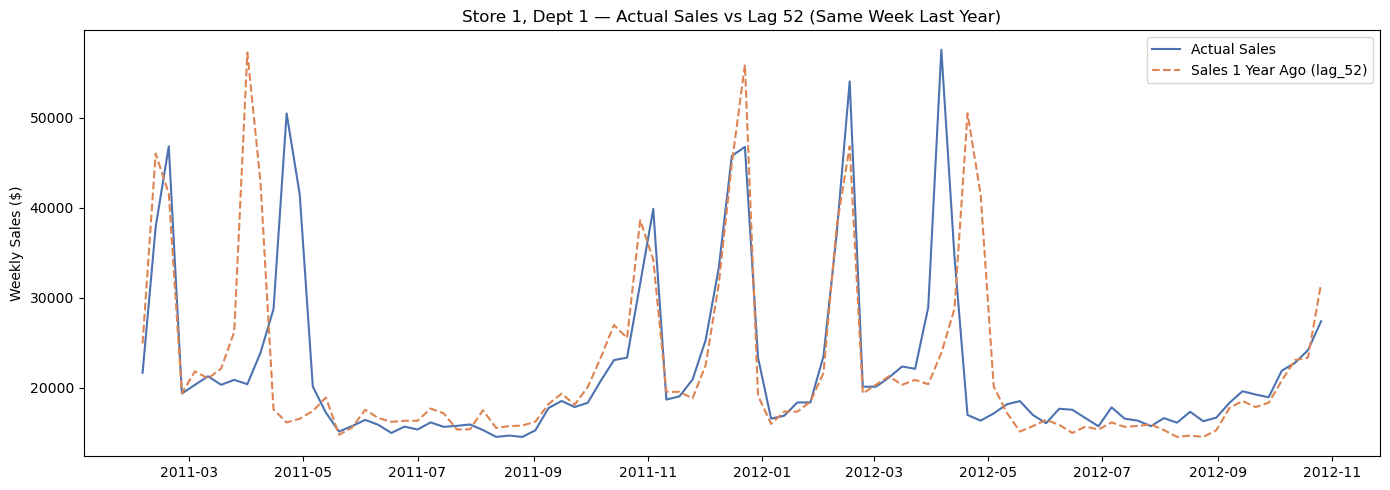

If the dashed line follows the solid line closely = lag_52 is a powerful feature!


In [8]:
# Use Store 1, Dept 1 as example
sample = df_features[
    (df_features["Store"] == 1) &
    (df_features["Dept"] == 1)
].dropna(subset=["lag_52"])

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(sample["Date"], sample["Weekly_Sales"], label="Actual Sales", color="#4C72B0", linewidth=1.5)
ax.plot(sample["Date"], sample["lag_52"], label="Sales 1 Year Ago (lag_52)",
        color="#DD8452", linewidth=1.5, linestyle="--")
ax.set_title("Store 1, Dept 1 — Actual Sales vs Lag 52 (Same Week Last Year)")
ax.set_ylabel("Weekly Sales ($)")
ax.legend()
plt.tight_layout()
plt.savefig("reports/figures/08_lag52_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("If the dashed line follows the solid line closely = lag_52 is a powerful feature!")

In [9]:
import os
os.makedirs("data/processed", exist_ok=True)

df_features.to_parquet("data/processed/train_features.parquet", index=False)

print("Saved to: data/processed/train_features.parquet")
print("Final shape:", df_features.shape)
print(f"Total columns: {len(df_features.columns)}")
print("\nPhase 3 Complete!")

Saved to: data/processed/train_features.parquet
Final shape: (408436, 46)
Total columns: 46

Phase 3 Complete!
